In [1]:
from pycirclize import Circos
import pandas as pd

In [6]:
names = [
    'GW10',
 'GW12',
 'GW13_rep',
 'GW13',
 'GW16',
]
cell_colors = {'29': '#a3dc1f',
 '00': '#5ef377',
 '02': '#654c0d',
 '27': '#aea266',
 '03': '#e4f36b',
 '23': '#2a74d1',
 '06': '#1426db',
 '25': '#e93f06',
 '16': '#8caec2',
 '28': '#db3529',
 '18': '#215789',
 '22': '#490ea7',
 '21': '#7a7bc3',
 '14': '#0d204c',
 '19': '#4ae86f',
 '20': '#efb6a4',
 '04': '#f55fb7',
 '13': '#ccb347',
 '26': '#b36428',
 '09': '#efea60',
 '17': '#30fac0',
 '12': '#cee3d7',
 '08': '#8a1ecb',
 '07': '#607f79',
 '15': '#3a6152',
 '24': '#91a6de',
 '10': '#779d25',
 '11': '#524ae3',
 '05': '#1164b8',
 '01': '#1f8071'}

for name in names:
    true_name = name.replace('.h5ad', '')
    csv = pd.read_csv(f'/data/work/05.cluster/FuseMap/0313/mh_boundary/cci/{true_name}.csv')
    csv = csv[csv['is_significant'] == True]
    csv = csv[csv['lr_co_exp_ratio_pvalue'] < 0.01]
    csv['SourceID'] = [i.split('-')[0].replace('mh_sc_', '') for i in csv['sr_pair']]
    
    csv['DestinationID'] = [i.split('-')[1].replace('mh_sc_', '') for i in csv['sr_pair']]
    csv['Ligand'] = [i.split('-')[0] for i in csv['lr_pair']]
    csv['Receptor'] = [i.split('-')[1] for i in csv['lr_pair']]
    csv['select'] = [True if 'CD' in i else False for i in csv['Ligand']]
    csv = csv[csv['select'] == False]
    csv['select'] = [True if 'CD' in i else False for i in csv['Receptor']]
    csv = csv[csv['select'] == False]
    # links = csv.groupby(['SourceGene', 'TargetGene', 'SourceID', 'DestinationID'], as_index=False)['lr_co_exp_num'].sum()

    # links.columns = ['source_gene', 'target_gene', 'source_cell', 'target_cell', 'value']
    links = csv.groupby(['SourceID', 'DestinationID'], as_index=False)['lr_co_exp_num'].sum()

    matrix = links.pivot(index='SourceID', columns='DestinationID', values='lr_co_exp_num')

    # 填充缺失值为 0（如果某些组合不存在）
    matrix = matrix.fillna(0)

    def link_kws_handler(from_label: str, to_label: str):
        if from_label in ("08") or to_label in ("08"):
            # Set alpha, zorder values higher than other links for highlighting
            return dict(alpha=0.5, zorder=1.0)
        else:
            return dict(alpha=0.1, zorder=0)

    # Initialize Circos instance for chord diagram plot
    circos = Circos.chord_diagram(
        matrix,
        space=2,
        cmap=cell_colors,
        label_kws=dict(size=12),
        link_kws=dict(direction=1, ec="black", lw=0.5),
        link_kws_handler=link_kws_handler,
    )

    # fig = circos.plotfig()
    circos.savefig(f"/data/work/05.cluster/FuseMap/0313/mh_boundary/cciPlot/{true_name}.png")

In [ ]:
names = [
    'GW10',
 'GW12',
 'GW13_rep',
 'GW13',
 'GW16',
]
cell_colors = {'29': '#a3dc1f',
 '00': '#5ef377',
 '02': '#654c0d',
 '27': '#aea266',
 '03': '#e4f36b',
 '23': '#2a74d1',
 '06': '#1426db',
 '25': '#e93f06',
 '16': '#8caec2',
 '28': '#db3529',
 '18': '#215789',
 '22': '#490ea7',
 '21': '#7a7bc3',
 '14': '#0d204c',
 '19': '#4ae86f',
 '20': '#efb6a4',
 '04': '#f55fb7',
 '13': '#ccb347',
 '26': '#b36428',
 '09': '#efea60',
 '17': '#30fac0',
 '12': '#cee3d7',
 '08': '#8a1ecb',
 '07': '#607f79',
 '15': '#3a6152',
 '24': '#91a6de',
 '10': '#779d25',
 '11': '#524ae3',
 '05': '#1164b8',
 '01': '#1f8071'}

for name in names:
    true_name = name.replace('.h5ad', '')
    csv = pd.read_csv(f'/data/work/05.cluster/FuseMap/0313/mh_boundary/cci/{true_name}.csv')
    csv = csv[csv['is_significant'] == True]
    csv = csv[csv['lr_co_exp_ratio_pvalue'] < 0.01]
    csv['SourceID'] = [i.split('-')[0].replace('mh_sc_', '') for i in csv['sr_pair']]
    
    csv['DestinationID'] = [i.split('-')[1].replace('mh_sc_', '') for i in csv['sr_pair']]
    csv['Ligand'] = [i.split('-')[0] for i in csv['lr_pair']]
    csv['Receptor'] = [i.split('-')[1] for i in csv['lr_pair']]
    csv['select'] = [True if 'CD' in i else False for i in csv['Ligand']]
    csv = csv[csv['select'] == False]
    csv['select'] = [True if 'CD' in i else False for i in csv['Receptor']]
    csv = csv[csv['select'] == False]
    # links = csv.groupby(['SourceGene', 'TargetGene', 'SourceID', 'DestinationID'], as_index=False)['lr_co_exp_num'].sum()

    # links.columns = ['source_gene', 'target_gene', 'source_cell', 'target_cell', 'value']
    links = csv.groupby(['SourceID', 'DestinationID'], as_index=False)['lr_co_exp_num'].sum()

    matrix = links.pivot(index='SourceID', columns='DestinationID', values='lr_co_exp_num')

    # 填充缺失值为 0（如果某些组合不存在）
    matrix = matrix.fillna(0)

    def link_kws_handler(from_label: str, to_label: str):
        if from_label in ("08") or to_label in ("08"):
            # Set alpha, zorder values higher than other links for highlighting
            return dict(alpha=0.5, zorder=1.0)
        else:
            return dict(alpha=0.1, zorder=0)

    # Initialize Circos instance for chord diagram plot
    circos = Circos.chord_diagram(
        matrix,
        space=2,
        cmap=cell_colors,
        label_kws=dict(size=12),
        link_kws=dict(direction=1, ec="black", lw=0.5),
        link_kws_handler=link_kws_handler,
    )

    # fig = circos.plotfig()
    circos.savefig(f"/data/work/05.cluster/FuseMap/0313/mh_boundary/cciPlot/{true_name}.png")

In [7]:
names = [
    'GW10',
 'GW12',
 'GW13_rep',
 'GW13',
 'GW16',
]
cell_colors = {'29': '#a3dc1f',
 '00': '#5ef377',
 '02': '#654c0d',
 '27': '#aea266',
 '03': '#e4f36b',
 '23': '#2a74d1',
 '06': '#1426db',
 '25': '#e93f06',
 '16': '#8caec2',
 '28': '#db3529',
 '18': '#215789',
 '22': '#490ea7',
 '21': '#7a7bc3',
 '14': '#0d204c',
 '19': '#4ae86f',
 '20': '#efb6a4',
 '04': '#f55fb7',
 '13': '#ccb347',
 '26': '#b36428',
 '09': '#efea60',
 '17': '#30fac0',
 '12': '#cee3d7',
 '08': '#8a1ecb',
 '07': '#607f79',
 '15': '#3a6152',
 '24': '#91a6de',
 '10': '#779d25',
 '11': '#524ae3',
 '05': '#1164b8',
 '01': '#1f8071'}

for name in names:
    true_name = name.replace('.h5ad', '')
    csv = pd.read_csv(f'/data/work/05.cluster/FuseMap/0313/mh_boundary/cci/{true_name}.csv')
    csv = csv[csv['is_significant'] == True]
    csv = csv[csv['lr_co_exp_ratio_pvalue'] < 0.01]
    csv['SourceID'] = [i.split('-')[0].replace('mh_sc_', '') for i in csv['sr_pair']]
    
    csv['DestinationID'] = [i.split('-')[1].replace('mh_sc_', '') for i in csv['sr_pair']]
    csv['Ligand'] = [i.split('-')[0] for i in csv['lr_pair']]
    csv['Receptor'] = [i.split('-')[1] for i in csv['lr_pair']]
    csv['select'] = [True if 'CD' in i else False for i in csv['Ligand']]
    csv = csv[csv['select'] == False]
    csv['select'] = [True if 'CD' in i else False for i in csv['Receptor']]
    csv = csv[csv['select'] == False]
    # links = csv.groupby(['SourceGene', 'TargetGene', 'SourceID', 'DestinationID'], as_index=False)['lr_co_exp_num'].sum()

    # links.columns = ['source_gene', 'target_gene', 'source_cell', 'target_cell', 'value']
    links = csv.groupby(['SourceID', 'DestinationID'], as_index=False)['lr_co_exp_num'].sum()

    matrix = links.pivot(index='SourceID', columns='DestinationID', values='lr_co_exp_num')

    # 填充缺失值为 0（如果某些组合不存在）
    matrix = matrix.fillna(0)

    def link_kws_handler(from_label: str, to_label: str):
        if from_label in ("17") or to_label in ("17"):
            # Set alpha, zorder values higher than other links for highlighting
            return dict(alpha=0.5, zorder=1.0)
        else:
            return dict(alpha=0.1, zorder=0)

    # Initialize Circos instance for chord diagram plot
    circos = Circos.chord_diagram(
        matrix,
        space=2,
        cmap=cell_colors,
        label_kws=dict(size=12),
        link_kws=dict(direction=1, ec="black", lw=0.5),
        link_kws_handler=link_kws_handler,
    )

    # fig = circos.plotfig()
    circos.savefig(f"/data/work/05.cluster/FuseMap/0313/mh_boundary/cciPlot_17/{true_name}.png")

In [2]:
names = [
    'GW10',
 'GW12',
 'GW13_rep',
 'GW13',
 'GW16',
]
cell_colors = {'29': '#a3dc1f',
 '00': '#5ef377',
 '02': '#654c0d',
 '27': '#aea266',
 '03': '#e4f36b',
 '23': '#2a74d1',
 '06': '#1426db',
 '25': '#e93f06',
 '16': '#8caec2',
 '28': '#db3529',
 '18': '#215789',
 '22': '#490ea7',
 '21': '#7a7bc3',
 '14': '#0d204c',
 '19': '#4ae86f',
 '20': '#efb6a4',
 '04': '#f55fb7',
 '13': '#ccb347',
 '26': '#b36428',
 '09': '#efea60',
 '17': '#30fac0',
 '12': '#cee3d7',
 '08': '#8a1ecb',
 '07': '#607f79',
 '15': '#3a6152',
 '24': '#91a6de',
 '10': '#779d25',
 '11': '#524ae3',
 '05': '#1164b8',
 '01': '#1f8071'}

for name in names:
    true_name = name.replace('.h5ad', '')
    csv = pd.read_csv(f'/data/work/05.cluster/FuseMap/0313/mh_boundary/cci/{true_name}.csv')
    csv = csv[csv['is_significant'] == True]
    csv = csv[csv['lr_co_exp_ratio_pvalue'] < 0.01]
    csv['SourceID'] = [i.split('-')[0].replace('mh_sc_', '') for i in csv['sr_pair']]
    
    csv['DestinationID'] = [i.split('-')[1].replace('mh_sc_', '') for i in csv['sr_pair']]
    csv['Ligand'] = [i.split('-')[0] for i in csv['lr_pair']]
    csv['Receptor'] = [i.split('-')[1] for i in csv['lr_pair']]
    csv['select'] = [True if 'CD' in i else False for i in csv['Ligand']]
    csv = csv[csv['select'] == False]
    csv['select'] = [True if 'CD' in i else False for i in csv['Receptor']]
    csv = csv[csv['select'] == False]
    # links = csv.groupby(['SourceGene', 'TargetGene', 'SourceID', 'DestinationID'], as_index=False)['lr_co_exp_num'].sum()

    # links.columns = ['source_gene', 'target_gene', 'source_cell', 'target_cell', 'value']
    links = csv.groupby(['SourceID', 'DestinationID'], as_index=False)['lr_co_exp_num'].sum()

    matrix = links.pivot(index='SourceID', columns='DestinationID', values='lr_co_exp_num')

    # 填充缺失值为 0（如果某些组合不存在）
    matrix = matrix.fillna(0)

    def link_kws_handler(from_label: str, to_label: str):
        if from_label in ("17") or to_label in ("17"):
            # Set alpha, zorder values higher than other links for highlighting
            return dict(alpha=0.5, zorder=1.0)
        else:
            return dict(alpha=0.1, zorder=0)

    # Initialize Circos instance for chord diagram plot
    circos = Circos.chord_diagram(
        matrix,
        space=2,
        cmap=cell_colors,
        label_kws=dict(size=12),
        link_kws=dict(direction=1, ec="black", lw=0.5),
        link_kws_handler=link_kws_handler,
    )

    # fig = circos.plotfig()
    circos.savefig(f"/data/work/05.cluster/FuseMap/0313/mh_boundary/cciPlot_17/{true_name}.pdf")

In [85]:
csv.columns

Index(['Unnamed: 0', 'from', 'to', 'pathway', 'type', 'lr_pair', 'lr_product',
       'lr_co_exp_num', 'lr_co_exp_ratio', 'lr_co_exp_ratio_pvalue',
       'is_significant', 'sr_pair', 'SourceID', 'DestinationID', 'Ligand',
       'Receptor', 'SourceGene', 'TargetGene'],
      dtype='object')

In [76]:
all_cells = list(set(links['source_cell'].tolist()) | set(links['target_cell'].tolist()))
for each_cell in all_cells:
    

{'mh_sc_02',
 'mh_sc_08',
 'mh_sc_13',
 'mh_sc_14',
 'mh_sc_19',
 'mh_sc_20',
 'mh_sc_26',
 'mh_sc_28',
 'mh_sc_29'}

In [70]:
sectors_links = links.groupby('source_cell')['value'].sum()
sectors = sectors_links.to_dict()
circos = Circos(sectors, space=len(sectors))
for sector in circos.sectors:
    sector.text(f"{sector.name}", r=105, size=10)
    track = sector.add_track((90, 100), r_pad_ratio=0.1)
    track.axis(fc=cell_colors[sector.name])


circos.link(("A", 0, 3), ("B", 15, 12))
circos.savefig("example01.png")

In [47]:
import matplotlib.pyplot as plt

# 定义颜色映射


# 绘制弦图
circos = Circos.chord_diagram(
    matrix_df,
    space=2,
    cmap="Set3",
    label_kws=dict(size=12),
    link_kws=dict(direction=1, ec="black", lw=0.5),
)

# 添加外圈细胞类型标注
for i, gene in enumerate(matrix_df.index):
    cell_type = gene_to_cell[gene]
    color = cell_colors[cell_type]
    circos.add_outer_ring(i, color=color, width=0.1)

# 保存图像
circos.savefig("example_with_cell_types.png")

AttributeError: 'Circos' object has no attribute 'add_outer_ring'

In [36]:
for lr_pair, matrix in multi_layer_matrix.items():
    circos = Circos.chord_diagram(
        matrix,
        space=2,
        cmap="Set3",
        label_kws=dict(size=12),
        link_kws=dict(direction=1, ec="black", lw=0.5),
        link_kws_handler=link_kws_handler,
    )
    circos.savefig(f"example_{lr_pair}.png")

In [34]:
from matplotlib.colors import ListedColormap

# 定义颜色映射
# cmap = ListedColormap(["red", "blue", "green", "purple"])  # 根据配体-受体对数量调整颜色

# 绘制叠加图
circos = Circos.chord_diagram(
    sum(multi_layer_matrix.values()),  # 合并所有矩阵
    space=2,
    # cmap=cmap,
    label_kws=dict(size=12),
    link_kws=dict(direction=1, ec="black", lw=0.5),
    link_kws_handler=link_kws_handler,
)
circos.savefig("example_combined.png")

ZeroDivisionError: division by zero

In [27]:

links_agg = links.groupby(['source', 'target'], as_index=False)['value'].sum()

matrix_df = links_agg.pivot(index='source', columns='target', values='value')

matrix_df = matrix_df.fillna(0)

def link_kws_handler(from_label: str, to_label: str):
    if from_label in ("C", "G"):
        # Set alpha, zorder values higher than other links for highlighting
        return dict(alpha=0.5, zorder=1.0)
    else:
        return dict(alpha=0.1, zorder=0)

circos = Circos.chord_diagram(
    matrix_df,
    space=2,
    cmap="Set3",
    label_kws=dict(size=12),
    link_kws=dict(direction=1, ec="black", lw=0.5),
    link_kws_handler=link_kws_handler,
)

print(matrix_df)
circos.savefig("example02.png")

target    mh_sc_02  mh_sc_13  mh_sc_14  mh_sc_19  mh_sc_28
source                                                    
mh_sc_08       8.0       0.0       0.0       6.0       6.0
mh_sc_20       0.0      12.0       0.0       8.0       0.0
mh_sc_26       0.0       0.0       0.0       0.0       7.0
mh_sc_29       0.0       0.0      12.0       0.0       0.0


target    mh_sc_02  mh_sc_13  mh_sc_14  mh_sc_19  mh_sc_28
source                                                    
mh_sc_08       8.0       0.0       0.0       6.0       6.0
mh_sc_20       0.0      12.0       0.0       8.0       0.0
mh_sc_26       0.0       0.0       0.0       0.0       7.0
mh_sc_29       0.0       0.0      12.0       0.0       0.0


In [25]:
matrix_df

NameError: name 'matrix_df' is not defined

In [18]:
hv.Chord(links)

:Chord   [source,target]   (value)

In [20]:
hv.Chord((links, csv)).select(value=(5, None)).opts(
    opts.Chord(cmap='Category20', edge_color=dim('source').astype(str), labels='from', node_color=dim('index').astype(str)))

AttributeError: 'DataFrame' object has no attribute 'ndims'

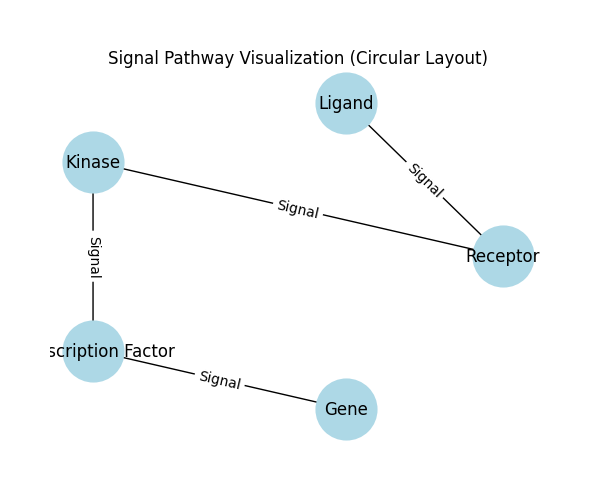

In [49]:
import networkx as nx
import matplotlib.pyplot as plt

# 创建一个有向图
G = nx.DiGraph()

# 添加节点（信号通路中的分子或蛋白质）
nodes = ["Receptor", "Ligand", "Kinase", "Transcription Factor", "Gene"]
G.add_nodes_from(nodes)

# 添加边（表示信号传递关系）
edges = [
    ("Ligand", "Receptor"),
    ("Receptor", "Kinase"),
    ("Kinase", "Transcription Factor"),
    ("Transcription Factor", "Gene")
]
G.add_edges_from(edges)

# 使用环形布局
pos = nx.circular_layout(G)  # 将节点均匀分布在圆周上

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="lightblue")

# 绘制边
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20)

# 添加节点标签
nx.draw_networkx_labels(G, pos, font_size=12, font_color="black")

# 添加边标签（可选）
edge_labels = {edge: "Signal" for edge in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# 显示图形
plt.title("Signal Pathway Visualization (Circular Layout)")
plt.axis("off")  # 关闭坐标轴
plt.show()